# Final Project

Project Activities:
1. Understanding the Dataset
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Modeling
6. Model Tuning
7. Model Interpretation
8. Presentation

## 0. Libraries and Global Settings

In [79]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.model_selection import ( 
    train_test_split, cross_validate, 
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, 
    GradientBoostingClassifier, AdaBoostClassifier
)

# Folder for project outputs
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

## 1. Understanding the Dataset: Dataset Exploration

### Load dataset and inspect structure

In [51]:
DATA_PATH = "final_project_dataset_complete.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape: ", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Dataset shape:  (9000, 11)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
feature_1,9000.0,NaN,NaN,NaN,0.000427,1.241318,-18.6654,-0.680062,-0.003938,0.680513,21.934496
feature_2,9000.0,NaN,NaN,NaN,0.003349,2.508324,-37.852816,-1.38261,-0.016698,1.380228,47.603454
feature_3,8600.0,NaN,NaN,NaN,0.003235,1.542901,-6.67668,-1.022085,0.005196,1.038571,6.203055
feature_4,9000.0,NaN,NaN,NaN,-0.008481,2.061784,-8.190124,-1.399928,-0.019541,1.394151,8.189001
feature_5,9000.0,NaN,NaN,NaN,-0.002177,0.577415,-0.999791,-0.502614,0.001695,0.497004,0.999914
feature_6,8500.0,NaN,NaN,NaN,-0.006447,1.981615,-8.590782,-1.32904,-0.003137,1.324897,6.803751
feature_7,9000.0,NaN,NaN,NaN,0.000592,1.075064,-4.422265,-0.700078,-0.000097,0.731942,3.857219
feature_8,9000.0,NaN,NaN,NaN,0.003348,2.043643,-9.474989,-1.35662,-0.007584,1.402024,7.572578
category_1,9000,4,Low,2802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_2,9000,3,Region B,3618,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Identify target and feature groups
target_col = "target"
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.drop(target_col).tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Target:", target_col)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Target: target
Numerical features: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8']
Categorical features: ['category_1', 'category_2']


In [53]:
# Missing values
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_table)

,missing_count,missing_percent
feature_6,500,5.56
feature_3,400,4.44
feature_1,0,0.00
feature_2,0,0.00
feature_4,0,0.00
feature_5,0,0.00
feature_7,0,0.00
feature_8,0,0.00
category_1,0,0.00
category_2,0,0.00


,target,count,percent
0,0,4721,52.46
1,1,4279,47.54


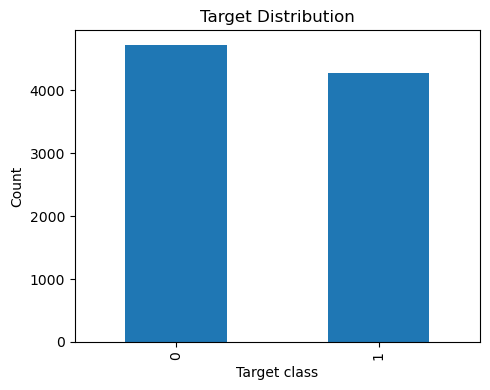

In [54]:
# Visualize target distribution
target_distribution = df[target_col].value_counts().rename_axis("target").reset_index(name="count")
target_distribution["percent"] = (target_distribution["count"] / len(df) * 100).round(2)
display(target_distribution)

plt.figure(figsize=(5, 4))
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/figures/target_distribution.png", dpi=150)
plt.show()

### Visualize distributions of numerical features.

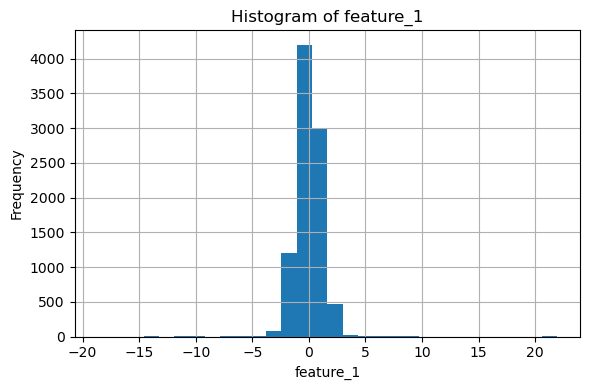

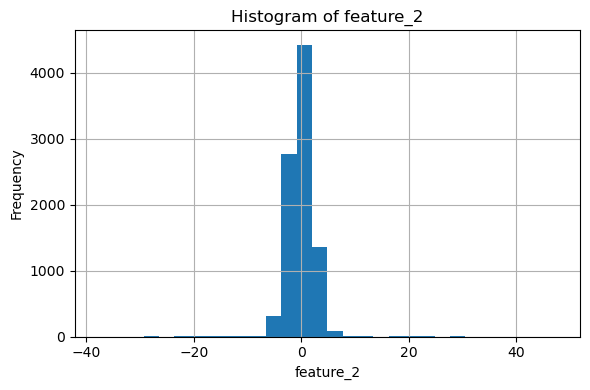

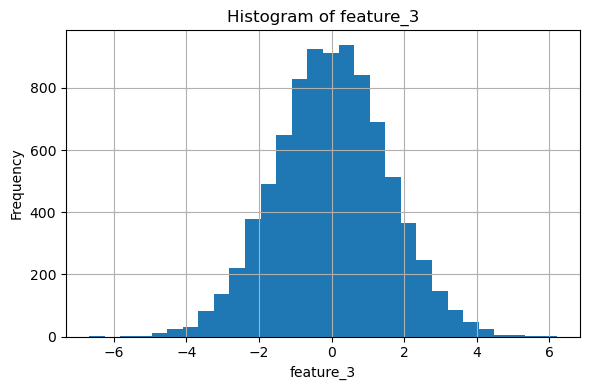

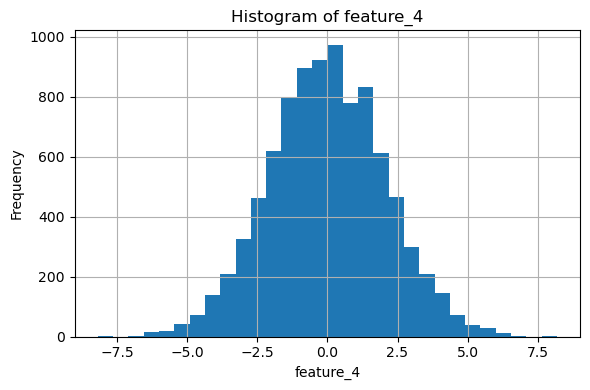

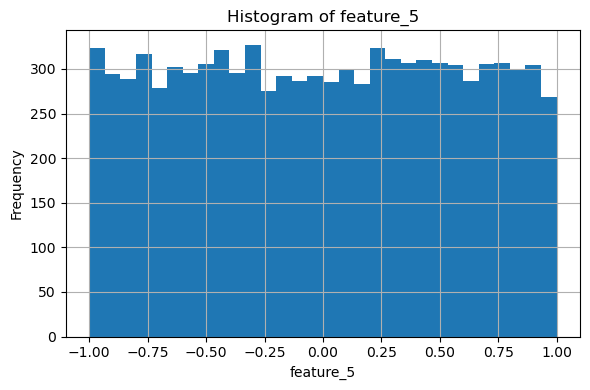

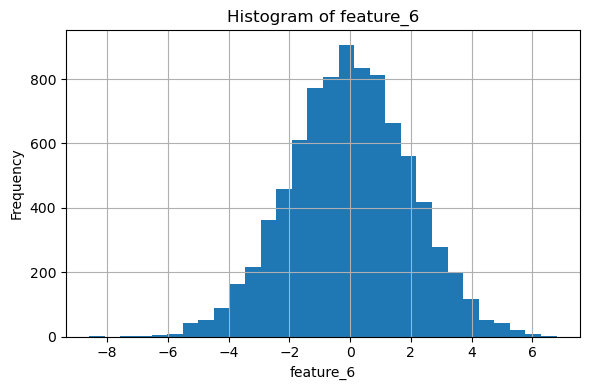

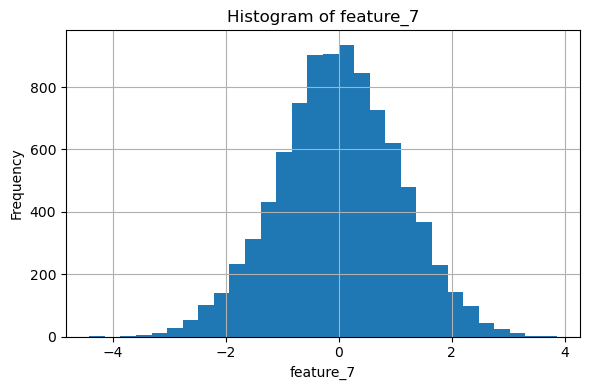

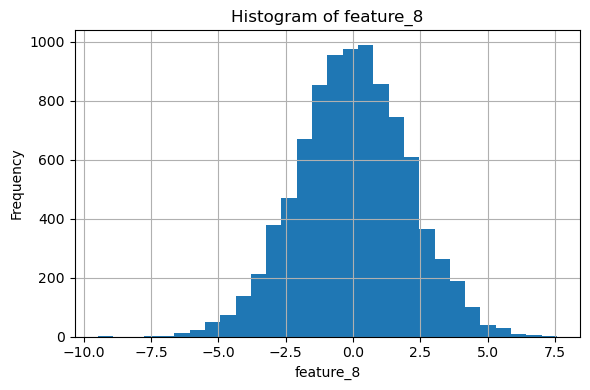

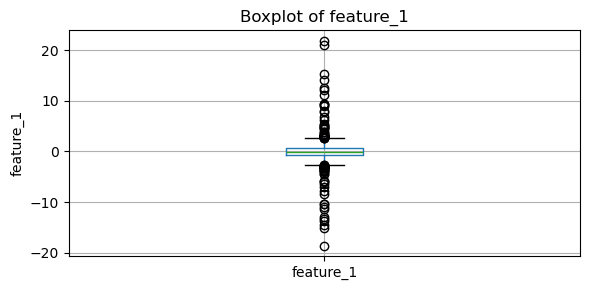

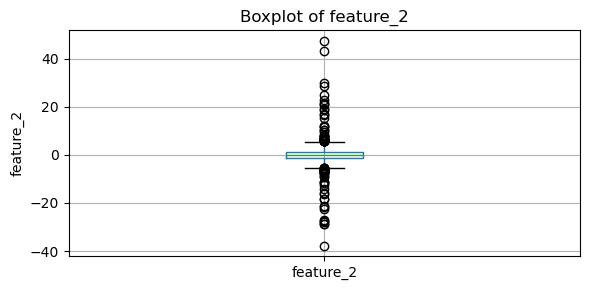

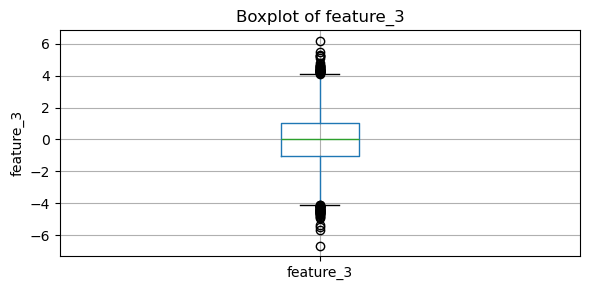

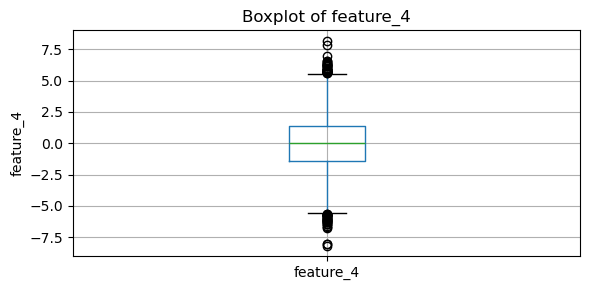

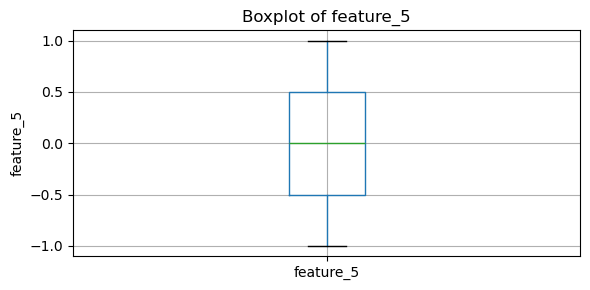

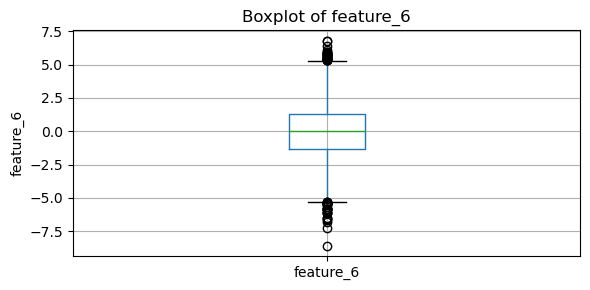

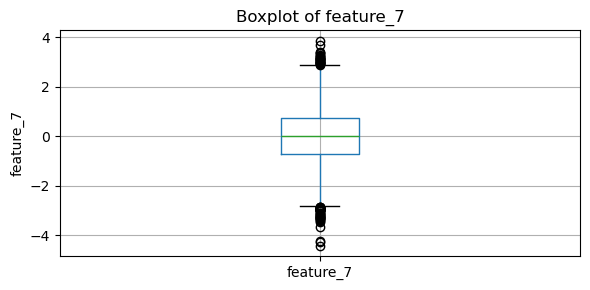

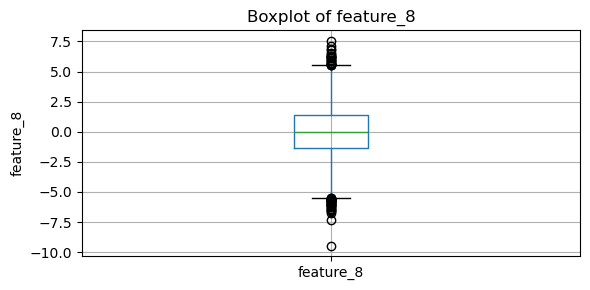

In [55]:
# Histograms for numerical features
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/histogram_{col}.png", dpi=150)
    plt.show()

# Boxplots for numerical features
for col in numeric_features:
    plt.figure(figsize=(6, 3))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"outputs/figures/boxplot_{col}.png", dpi=150)
    plt.show()

### Analyze relationships between numerical features and target variable using scatter plots and correlation matrices.

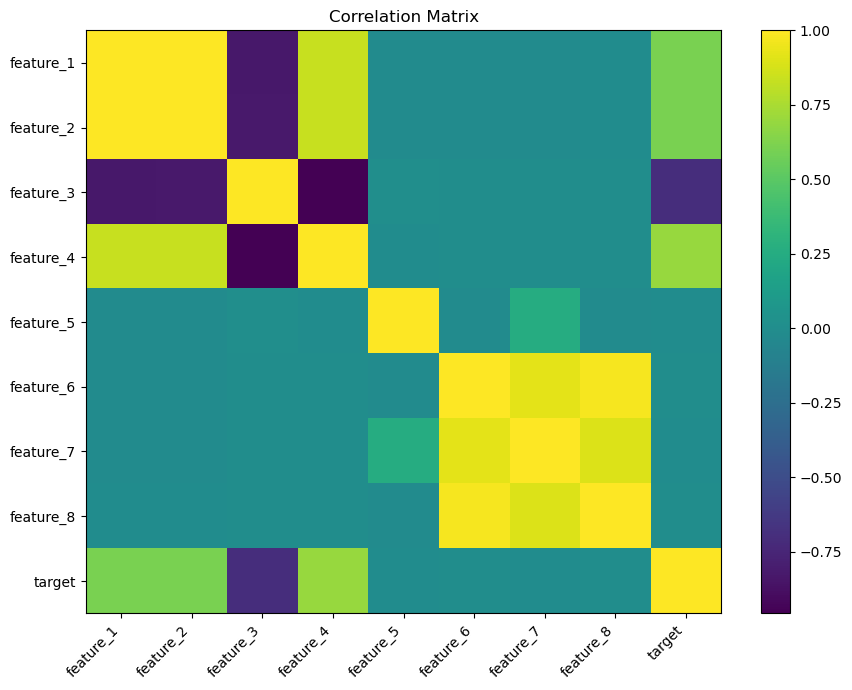

target       1.000000
feature_4    0.694885
feature_2    0.606016
feature_1    0.605940
feature_8    0.004658
feature_6    0.001457
feature_7   -0.002000
feature_5   -0.007873
feature_3   -0.704351
Name: target, dtype: float64

In [56]:
# Correlation matrix and initial feature-target relationships
corr = df[numeric_features + [target_col]].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(
    range(len(corr.columns)), 
    corr.columns, 
    rotation=45, 
    ha='right'
    )
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs/figures/correlation_matrix.png", dpi=150)
plt.show()

display(corr[target_col].sort_values(ascending=False))

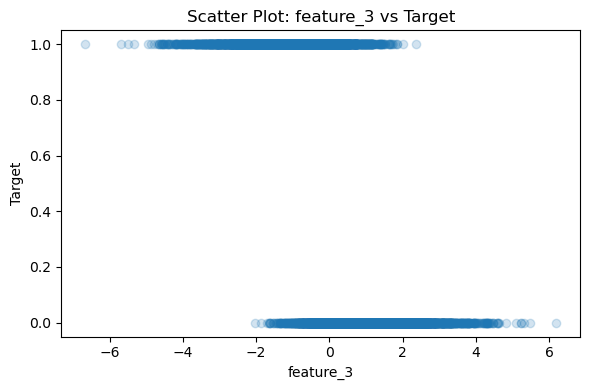

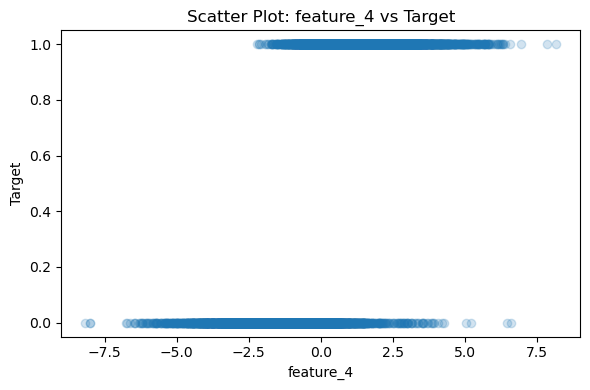

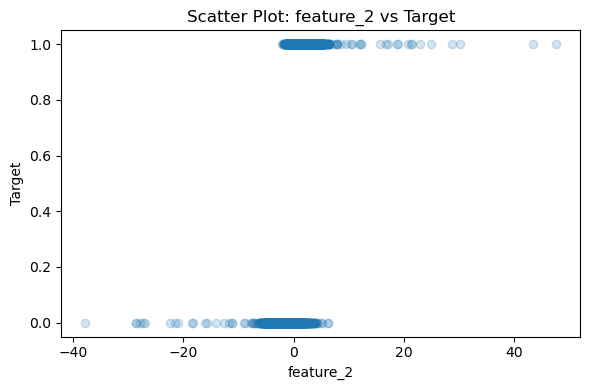

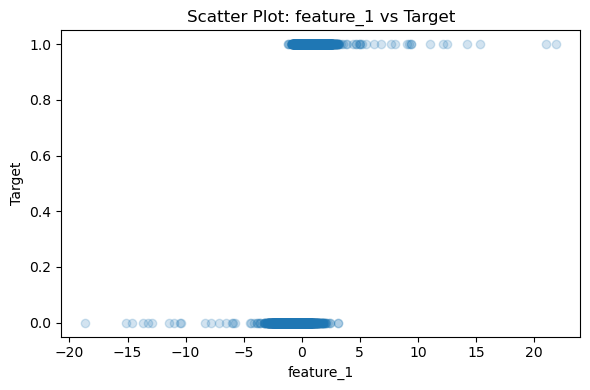

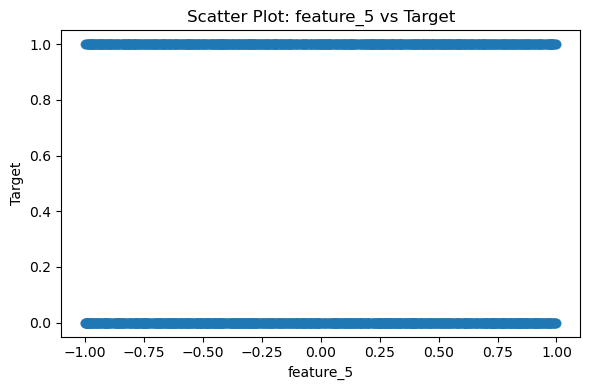

In [57]:
# Scatter plots for numerical features against the target variable
strong_cols = corr[target_col].abs().sort_values(ascending=False).index[1:6]  # Top 5 features with strongest correlation

for col in strong_cols:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df[target_col], alpha=0.2)
    plt.xlabel(col)
    plt.ylabel("Target")
    plt.title(f"Scatter Plot: {col} vs Target")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/scatter_{col}_target.png", dpi=150)
    plt.show()

## 2. Data Preprocessing: Data Cleaning and Preparation

### Outlier analysis using IQR rule

In [58]:
outlier_summary = []

for col in numeric_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,feature_1,-2.720924,2.721374,113,1.26
1,feature_2,-5.526868,5.524486,106,1.18
2,feature_3,-4.113068,4.129554,75,0.83
3,feature_4,-5.591048,5.585270,71,0.79
4,feature_5,-2.002042,1.996432,0,0.00
5,feature_6,-5.309945,5.305802,59,0.66
6,feature_7,-2.848108,2.879971,69,0.77
7,feature_8,-5.494586,5.539990,61,0.68


### Clean dataset: impute missing values and clip outliers

In [59]:
df_clean = df.copy()

# Missing numerical values are imputed with median.
# Median is robust to outliers and works well for skewed distributions.
for col in numeric_features:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

# Outliers are clipped using the IQR bounds.
# This keeps all observations while reducing the influence of extreme values.
for col in numeric_features:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower, upper)

df_clean.to_csv("outputs/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved to outputs/cleaned_dataset.csv")
display(df_clean.head())
display(df_clean.isna().sum())

Cleaned dataset saved to outputs/cleaned_dataset.csv


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
category_1    0
category_2    0
target        0
dtype: int64

### Preprocessing pipeline for machine learning

In [60]:
# Numerical pipeline:
# - impute missing values
# - scale numerical features for algorithms sensitive to scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline:
# - impute missing values
# - one-hot encode categories
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 3. Exploratory Data Analysis (EDA): In-depth EDA

### Correlation Matrix and Heatmap

In [61]:
# Correlation Matrix for Numerical Variables
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# If the target column is not numerical, we temporarily encode it for correlation analysis
df_corr = df_clean.copy()

if df_corr[target_col].dtype == "object" or df_corr[target_col].dtype.name == "category":
    df_corr[target_col + "_encoded"] = df_corr[target_col].astype("category").cat.codes
    corr_target_col = target_col + "_encoded"
else:
    corr_target_col = target_col

numeric_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr_matrix = df_corr[numeric_cols].corr()
display(corr_matrix)

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.994946,-0.951877,0.966247,-0.008219,-0.003841,-0.005264,-0.000279,0.704458
feature_2,0.994946,1.000000,-0.946409,0.970446,-0.007444,-0.004337,-0.005694,-0.000930,0.707481
feature_3,-0.951877,-0.946409,1.000000,-0.937409,0.011270,0.002804,0.005827,0.000919,-0.693399
feature_4,0.966247,0.970446,-0.937409,1.000000,-0.003590,0.000515,-0.001272,0.001560,0.697584
feature_5,-0.008219,-0.007444,0.011270,-0.003590,1.000000,-0.009075,0.251901,-0.013024,-0.007873
feature_6,-0.003841,-0.004337,0.002804,0.000515,-0.009075,1.000000,0.894626,0.939425,0.001850
feature_7,-0.005264,-0.005694,0.005827,-0.001272,0.251901,0.894626,1.000000,0.893992,-0.002097
feature_8,-0.000279,-0.000930,0.000919,0.001560,-0.013024,0.939425,0.893992,1.000000,0.004977
target,0.704458,0.707481,-0.693399,0.697584,-0.007873,0.001850,-0.002097,0.004977,1.000000


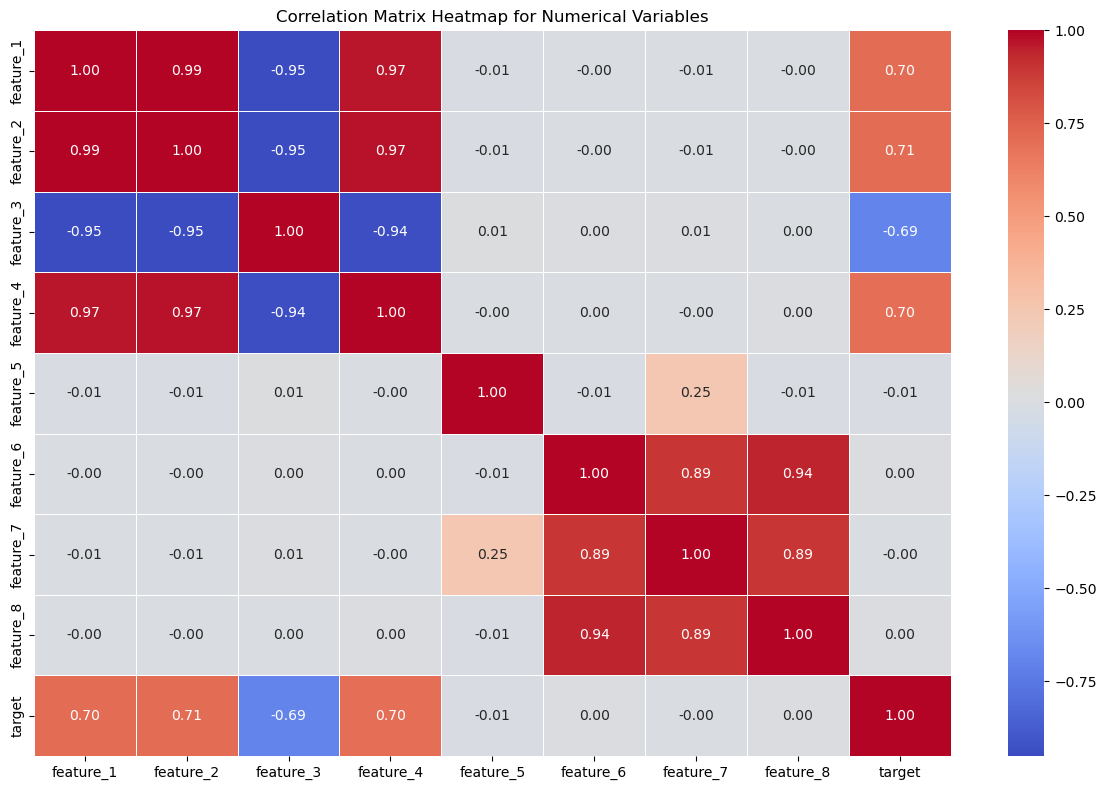

In [62]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix Heatmap for Numerical Variables")
plt.tight_layout()
plt.savefig("outputs/figures/correlation_matrix_heatmap.png", dpi=150)
plt.show()

In [63]:
# Correlation with Target Variable
target_corr = corr_matrix[corr_target_col].abs().sort_values(ascending=False)
target_corr = target_corr.drop(corr_target_col)
display(target_corr.head(10))

feature_2    0.707481
feature_1    0.704458
feature_4    0.697584
feature_3    0.693399
feature_5    0.007873
feature_8    0.004977
feature_7    0.002097
feature_6    0.001850
Name: target, dtype: float64

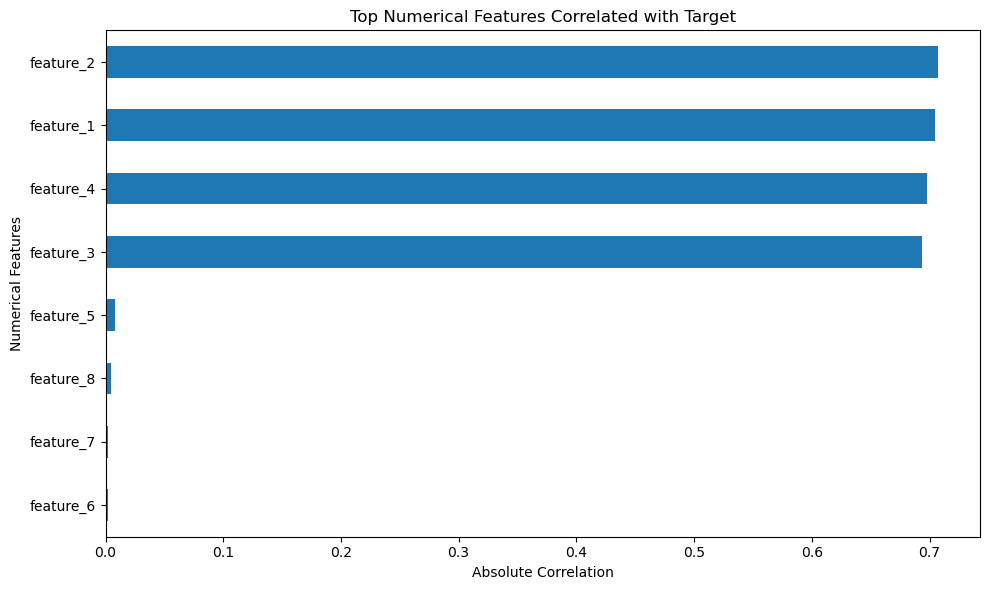

In [64]:
# Bar Chart: Top Numerical Features Correlated with Target
top_corr_features = target_corr.head(10)

plt.figure(figsize=(10, 6))
top_corr_features.sort_values().plot(kind="barh")
plt.title("Top Numerical Features Correlated with Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.savefig("outputs/figures/top_numerical_correlations_with_target.png", dpi=150)
plt.show()

### Numerical features by target class

<Figure size 600x400 with 0 Axes>

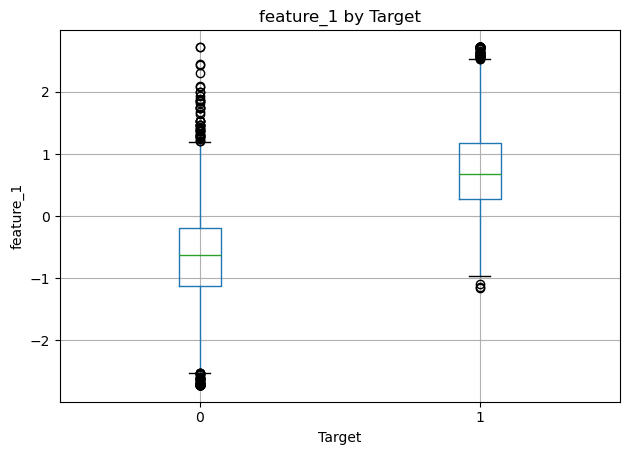

<Figure size 600x400 with 0 Axes>

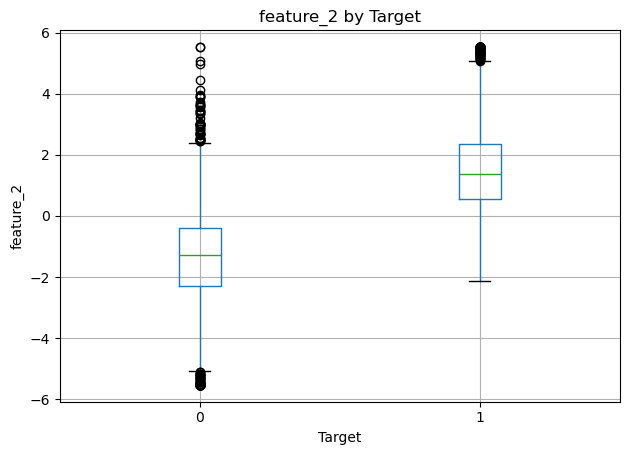

<Figure size 600x400 with 0 Axes>

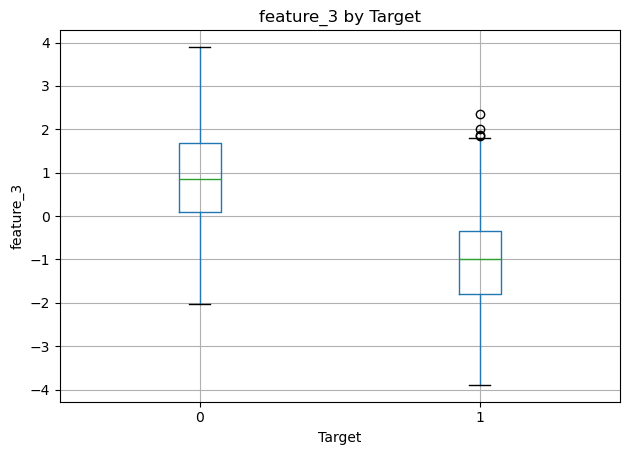

<Figure size 600x400 with 0 Axes>

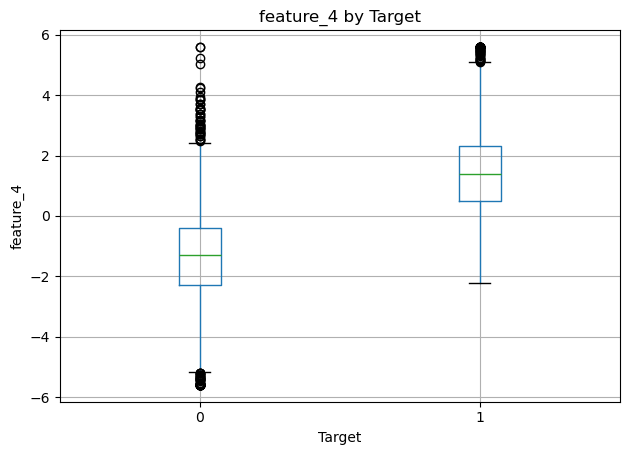

<Figure size 600x400 with 0 Axes>

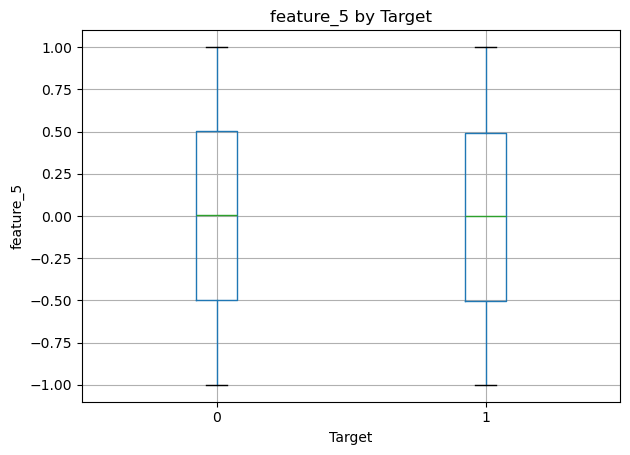

<Figure size 600x400 with 0 Axes>

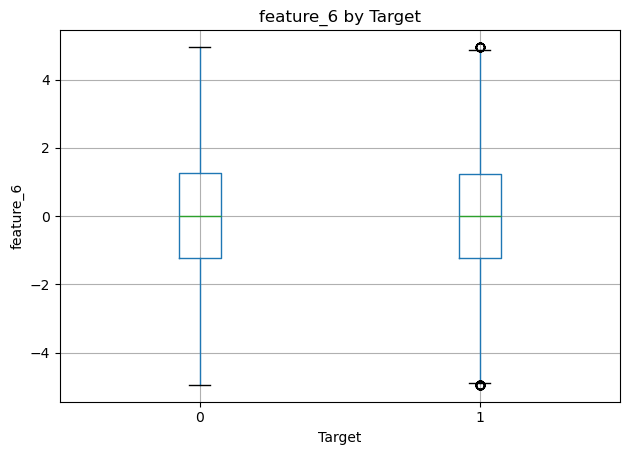

<Figure size 600x400 with 0 Axes>

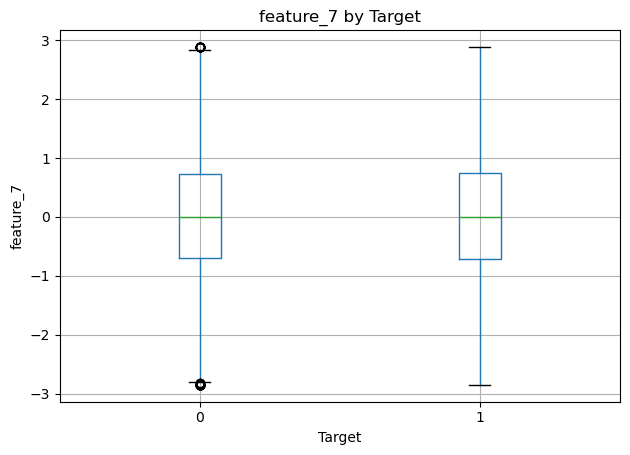

<Figure size 600x400 with 0 Axes>

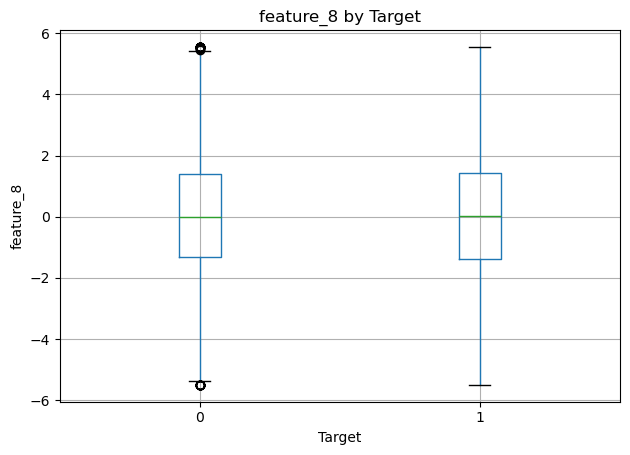

In [65]:
# Boxplots of Numerical Features by Target Class
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    df_clean.boxplot(column=col, by=target_col)
    plt.title(f"{col} by Target")
    plt.suptitle("")
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"outputs/figures/box_{col}_by_target.png", dpi=150)
    plt.show()

### Categorical features by target class

target,0,1
category_1,,
Above Average,0.329473,0.670527
Below Average,0.741218,0.258782
High,0.061889,0.938111
Low,0.968951,0.031049


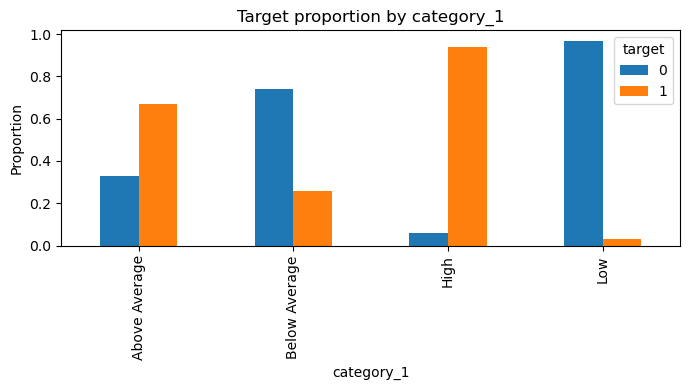

target,0,1
category_2,,
Region A,0.524923,0.475077
Region B,0.518795,0.481205
Region C,0.535227,0.464773


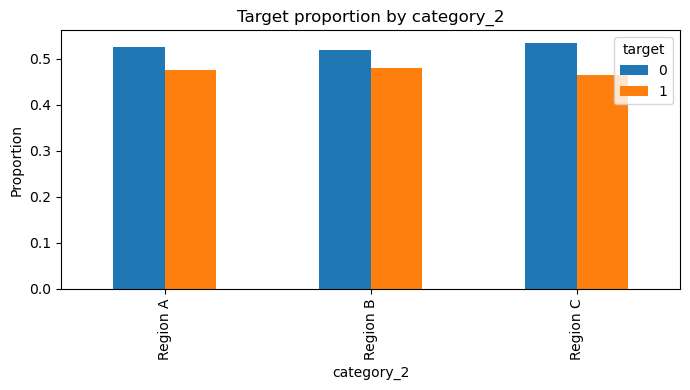

In [66]:
for col in categorical_features:
    crosstab = pd.crosstab(df_clean[col], df_clean[target_col], normalize="index")
    display(crosstab)

    crosstab.plot(kind="bar", figsize=(7, 4))
    plt.title(f"Target proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/{col}_target_proportion.png", dpi=150)
    plt.show()

### Hypothesis testing

In [67]:
# T-tests: checks whether numerical feature means differ between target classes.
ttest_results = []

for col in numeric_features:
    group_0 = df_clean[df_clean[target_col] == 0][col]
    group_1 = df_clean[df_clean[target_col] == 1][col]
    mean_target_0 = group_0.mean()
    mean_target_1 = group_1.mean()
    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)
    ttest_results.append({
        "feature": col,
        "mean_target_0": mean_target_0,
        "mean_target_1": mean_target_1,
        "t_statistic": t_stat,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    })

ttest_results = pd.DataFrame(ttest_results).sort_values("p_value")
display(ttest_results)

# Chi-square tests: checks whether categorical features are associated with target.
chi_results = []

for col in categorical_features:
    table = pd.crosstab(df_clean[col], df_clean[target_col])
    chi2, p_value, dof, expected = chi2_contingency(table)
    chi_results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    })

chi_results = pd.DataFrame(chi_results).sort_values("p_value")
display(chi_results)

,feature,mean_target_0,mean_target_1,t_statistic,p_value,significant_at_0.05
0,feature_1,-0.684054,0.752775,-94.485780,0.000000,True
1,feature_2,-1.380133,1.522863,-95.301975,0.000000,True
2,feature_3,0.987915,-1.082054,91.225537,0.000000,True
3,feature_4,-1.368116,1.492122,-92.661775,0.000000,True
4,feature_5,0.002150,-0.006952,0.747095,0.455026,False
7,feature_8,-0.005585,0.014659,-0.472199,0.636797,False
6,feature_7,0.003491,-0.000992,0.199045,0.842232,False
5,feature_6,-0.008392,-0.001335,-0.175652,0.860572,False


,feature,chi2,p_value,significant_at_0.05
0,category_1,5175.320287,0.00000,True
1,category_2,1.319349,0.51702,False


## 4. Feature Engineering: Create New Features

### Creating new features

In [68]:
df_fe = df_clean.copy()

# The strongest positive predictors from correlation analysis are feature_1, feature_2, feature_4.
# The strongest negative predictor is feature_3.
# The following features capture interaction, combined signal, and ratios.

df_fe["feature_1_feature_2_interaction"] = df_fe["feature_1"] * df_fe["feature_2"]
df_fe["feature_3_feature_4_interaction"] = df_fe["feature_3"] * df_fe["feature_4"]
df_fe["positive_signal_sum"] = df_fe["feature_1"] + df_fe["feature_2"] + df_fe["feature_4"]
df_fe["abs_feature_3"] = df_fe["feature_3"].abs()

# Ratio with small epsilon to avoid division by zero
epsilon = 1e-6
df_fe["feature_2_to_feature_3_ratio"] = df_fe["feature_2"] / (df_fe["feature_3"].abs() + epsilon)

# Domain-style aggregate: overall numerical activity / intensity
df_fe["overall_numerical_intensity"] = df_fe[numeric_features].mean(axis=1)
df_fe["overall_numerical_variability"] = df_fe[numeric_features].std(axis=1)

# Save deliverable D4.2
df_fe.to_csv("outputs/dataset_with_engineered_features.csv", index=False)

print("Dataset with engineered features saved to outputs/dataset_with_engineered_features.csv")
display(df_fe.head())

Dataset with engineered features saved to outputs/dataset_with_engineered_features.csv


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target,feature_1_feature_2_interaction,feature_3_feature_4_interaction,positive_signal_sum,abs_feature_3,feature_2_to_feature_3_ratio,overall_numerical_intensity,overall_numerical_variability
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1,0.569487,-0.540221,2.476228,0.648521,1.767880,-0.392394,1.396911
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0,0.008551,0.002098,0.203657,0.005196,-11.899245,-0.608320,1.166865
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1,0.903600,-1.305330,3.751070,0.764126,1.825764,0.923371,0.972024
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1,4.047543,-6.521045,6.829641,2.461653,1.079583,1.778222,1.924777
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0,0.116934,-0.254437,-1.175201,0.576097,-0.866852,0.094652,0.562373


### Updating feature lists after feature engineering

In [69]:
target_col = "target"
numeric_features_fe = df_fe.select_dtypes(include=["int64", "float64"]).columns.drop(target_col).tolist()
categorical_features_fe = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features after engineering:", numeric_features_fe)
print("Categorical features after engineering:", categorical_features_fe)

# New preprocessing pipeline for engineered dataset
numeric_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fe, numeric_features_fe),
        ("cat", categorical_transformer_fe, categorical_features_fe)
    ]
)

Numerical features after engineering: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_1_feature_2_interaction', 'feature_3_feature_4_interaction', 'positive_signal_sum', 'abs_feature_3', 'feature_2_to_feature_3_ratio', 'overall_numerical_intensity', 'overall_numerical_variability']
Categorical features after engineering: ['category_1', 'category_2']


## 5. Modeling: Build and Evaluate Models

### Train-test split

In [70]:
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:")
display(y_train.value_counts(normalize=True))
print("Test target distribution:")
display(y_test.value_counts(normalize=True))

Train shape: (7200, 17)
Test shape: (1800, 17)
Train target distribution:


target
0    0.524583
1    0.475417
Name: proportion, dtype: float64

Test target distribution:


target
0    0.524444
1    0.475556
Name: proportion, dtype: float64

### Define baseline and ensemble models

,model,accuracy,precision,recall,f1,roc_auc
4,Gradient Boosting,0.885556,0.891566,0.864486,0.877817,0.960793
2,Random Forest,0.890556,0.900365,0.865654,0.882668,0.958277
0,Logistic Regression,0.893333,0.899038,0.873832,0.886256,0.957398
3,Extra Trees,0.888333,0.897934,0.863318,0.880286,0.956916
5,AdaBoost,0.889444,0.902081,0.860981,0.881052,0.950091
1,Decision Tree,0.840556,0.834313,0.829439,0.831869,0.840037


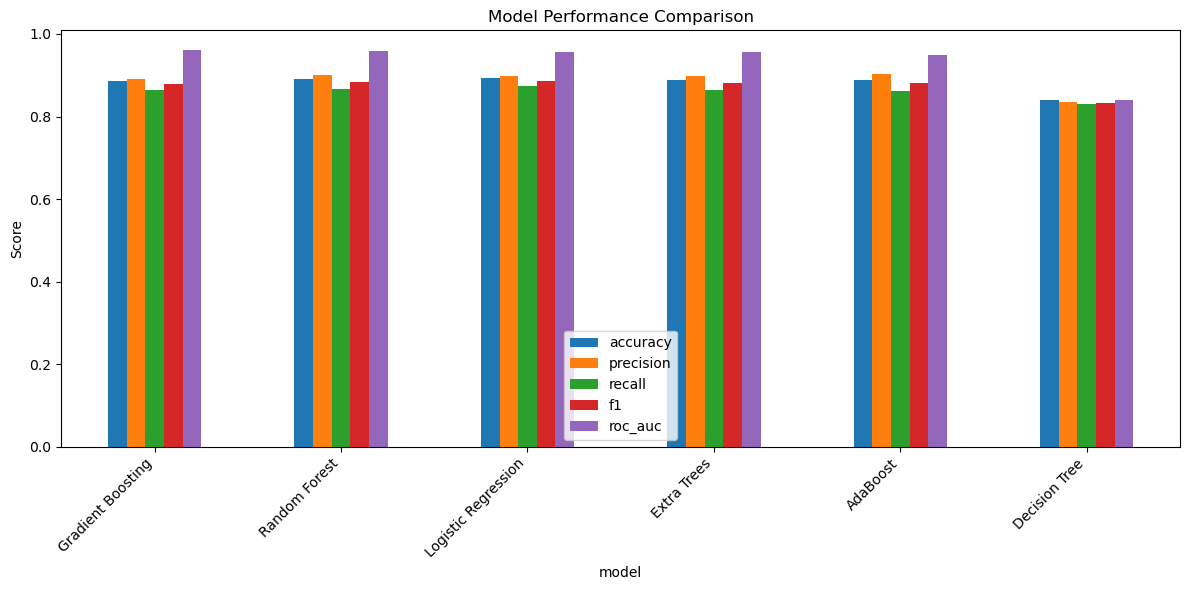

In [71]:
models = {
    # Baseline algorithms
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    # Ensemble learning models
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

# Train model and return test metrics
def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_fe),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # In our selected set of models, 
    # all classifiers support probability prediction through predict_proba(). 
    # However, we kept the hasattr() check as a defensive programming practice. 
    # This makes the evaluation function more flexible and prevents errors 
    # if future models without probability outputs are added.

    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # If a model does not support probability prediction, 
    # we assign None to avoid errors during evaluation.
    else:
        y_proba = None

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    return pipeline, result

trained_models = {}
results = []

for name, model in models.items():
    fitted_pipeline, metrics = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    trained_models[name] = fitted_pipeline
    results.append(metrics)
    joblib.dump(fitted_pipeline, f"outputs/models/{name.replace(' ', '_').lower()}.joblib")

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

results_df.plot(
    x="model", 
    y=["accuracy", "precision", "recall", "f1", "roc_auc"], 
    kind="bar", 
    figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("outputs/figures/model_performance_comparison.png", dpi=150)

results_df.to_csv("outputs/model_comparison.csv", index=False)

### Cross-validation

In [72]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, pipeline in trained_models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "model": name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_f1_std": scores["test_f1"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_roc_auc_mean", ascending=False)
display(cv_results_df)

cv_results_df.to_csv("outputs/cross_validation_results.csv", index=False)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_f1_mean,cv_f1_std
4,Gradient Boosting,0.957465,0.002462,0.867627,0.004227
2,Random Forest,0.955792,0.003579,0.871482,0.003537
0,Logistic Regression,0.953406,0.003872,0.874918,0.009311
3,Extra Trees,0.953209,0.002593,0.869369,0.004518
5,AdaBoost,0.949217,0.005646,0.864709,0.008055
1,Decision Tree,0.837746,0.009115,0.829982,0.009487


## 6. Model Tuning: Hyperparameter Tuning

### Hyperparameter tuning for ensemble models

In [73]:
tuning_spaces = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    },
    "Extra Trees": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.85, 1.0]
    }
}

base_estimators = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

tuned_results = []
tuned_models = {}

for name, estimator in base_estimators.items():
    print(f"Tuning {name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_fe),
        ("model", estimator)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=tuning_spaces[name],
        n_iter=20,
        scoring="roc_auc",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    tuned_pipeline = search.best_estimator_
    tuned_models[name] = tuned_pipeline

    y_pred = tuned_pipeline.predict(X_test)
    y_proba = tuned_pipeline.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "model": name,
        "best_params": search.best_params_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_proba)
    })

    display(pd.DataFrame([search.best_params_], index=[name]))

    joblib.dump(tuned_pipeline, f"outputs/models/tuned_{name.replace(' ', '_').lower()}.joblib")

tuned_results_df = pd.DataFrame(tuned_results).sort_values("test_roc_auc", ascending=False)
display(tuned_results_df)

tuned_results_df.to_csv("outputs/tuned_model_results.csv", index=False)

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
Random Forest,500,2,2,None,5


Tuning Extra Trees...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
Extra Trees,200,10,1,None,10


Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,model__subsample,model__n_estimators,model__max_depth,model__learning_rate
Gradient Boosting,0.7,50,4,0.05


,model,best_params,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Random Forest,"{'model__n_estimators': 500, 'model__min_sampl...",0.888889,0.900000,0.862150,0.880668,0.961674
2,Gradient Boosting,"{'model__subsample': 0.7, 'model__n_estimators...",0.888889,0.893285,0.870327,0.881657,0.961459
1,Extra Trees,"{'model__n_estimators': 200, 'model__min_sampl...",0.890556,0.903305,0.862150,0.882247,0.960317


### Compare default vs tuned models

,model,accuracy,precision,recall,f1,roc_auc,version
2,Extra Trees,0.888333,0.897934,0.863318,0.880286,0.956916,default
5,Extra Trees,0.890556,0.903305,0.862150,0.882247,0.960317,tuned
0,Gradient Boosting,0.885556,0.891566,0.864486,0.877817,0.960793,default
4,Gradient Boosting,0.888889,0.893285,0.870327,0.881657,0.961459,tuned
1,Random Forest,0.890556,0.900365,0.865654,0.882668,0.958277,default
3,Random Forest,0.888889,0.900000,0.862150,0.880668,0.961674,tuned


<Figure size 1200x600 with 0 Axes>

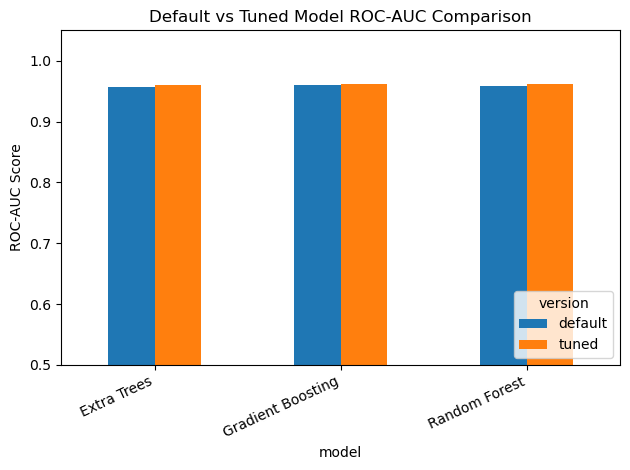

Best tuned model: Random Forest


['outputs/models/best_tuned_model.joblib']

In [74]:
default_subset = results_df[results_df["model"].isin(tuned_results_df["model"])][
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
].copy()

default_subset["version"] = "default"

tuned_subset = tuned_results_df[
    ["model", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]
].copy()
tuned_subset.columns = ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
tuned_subset["version"] = "tuned"

comparison_default_tuned = pd.concat([default_subset, tuned_subset], ignore_index=True)
display(comparison_default_tuned.sort_values(["model", "version"]))

comparison_default_tuned.to_csv("outputs/default_vs_tuned_comparison.csv", index=False)

comparison_pivot = comparison_default_tuned.pivot(
    index="model",
    columns="version",
    values="roc_auc"
)

plt.figure(figsize=(12, 6))
comparison_pivot.plot(kind="bar")
plt.title("Default vs Tuned Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.ylim(0.5, 1.05)
plt.xticks(rotation=25, ha='right')
plt.legend(title="version", loc='lower right')
plt.tight_layout()
plt.savefig("outputs/figures/default_vs_tuned_comparison.png", dpi=150)
plt.show()

best_tuned_name = tuned_results_df.iloc[0]["model"]
best_tuned_pipeline = tuned_models[best_tuned_name]

print("Best tuned model:", best_tuned_name)
joblib.dump(best_tuned_pipeline, "outputs/models/best_tuned_model.joblib")

## 7. Model Interpretation: Interpret the Model

### Feature names after preprocessing

In [75]:
# Return readable feature names after ColumnTransformer preprocessing.
def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):

    feature_names = []

    # Numerical features keep their names
    feature_names.extend(numeric_features)

    # Categorical features become one-hot encoded names
    onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = onehot.get_feature_names_out(categorical_features)
    feature_names.extend(cat_names)

    return np.array(feature_names)

# Fit preprocessor from the best tuned pipeline is already fitted
fitted_preprocessor = best_tuned_pipeline.named_steps["preprocessor"]
feature_names = get_feature_names_from_preprocessor(
    fitted_preprocessor,
    numeric_features_fe,
    categorical_features_fe
)

print("Number of transformed features:", len(feature_names))
print(feature_names[:20])

Number of transformed features: 22
['feature_1' 'feature_2' 'feature_3' 'feature_4' 'feature_5' 'feature_6'
 'feature_7' 'feature_8' 'feature_1_feature_2_interaction'
 'feature_3_feature_4_interaction' 'positive_signal_sum' 'abs_feature_3'
 'feature_2_to_feature_3_ratio' 'overall_numerical_intensity'
 'overall_numerical_variability' 'category_1_Above Average'
 'category_1_Below Average' 'category_1_High' 'category_1_Low'
 'category_2_Region A']


### Model-based feature importance, where available

,feature,importance
1,feature_2,3.546260e-01
0,feature_1,2.255965e-01
10,positive_signal_sum,2.108924e-01
11,abs_feature_3,8.968575e-02
12,feature_2_to_feature_3_ratio,6.550046e-02
8,feature_1_feature_2_interaction,2.715162e-02
2,feature_3,1.111112e-02
9,feature_3_feature_4_interaction,5.990518e-03
3,feature_4,2.152778e-03
4,feature_5,1.586236e-03


<Figure size 800x600 with 0 Axes>

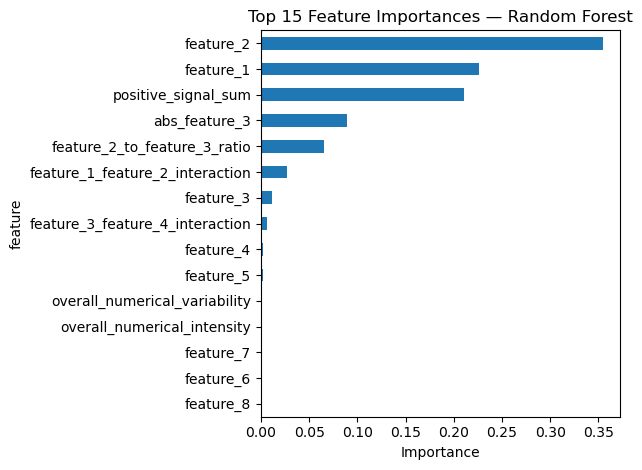

In [76]:
model_step = best_tuned_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(feature_importance_df.head(20))

    plt.figure(figsize=(8, 6))
    feature_importance_df.head(15).sort_values("importance").plot(
        x="feature", y="importance", kind="barh", legend=False
    )
    plt.title(f"Top 15 Feature Importances — {best_tuned_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("outputs/figures/feature_importance.png", dpi=150)
    plt.show()

    feature_importance_df.to_csv("outputs/feature_importance.csv", index=False)
else:
    print("This model does not provide built-in feature_importances_. Use permutation importance below.")

### SHAP interpretation

 95%|=================== | 946/1000 [00:13<00:00]       

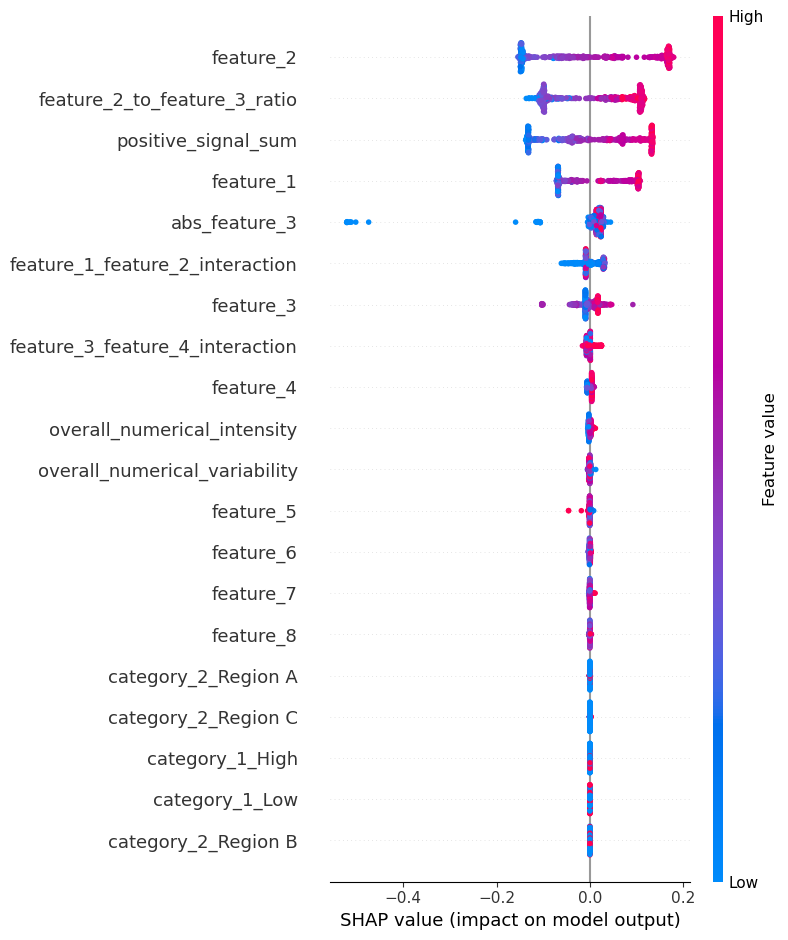

In [77]:
# Transform test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# Convert sparse matrix to dense if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Create SHAP explainer
explainer = shap.Explainer(
    model_step,
    X_test_transformed,
    feature_names=feature_names
)

# Calculate SHAP values for 500 observations
shap_values = explainer(X_test_transformed[:500])

# For binary classification, sometimes SHAP returns 3D values
values = shap_values.values

if values.ndim == 3:
    # select SHAP values for positive class
    values = values[:, :, 1]

# Regular SHAP summary plot
shap.summary_plot(
    values,
    X_test_transformed[:500],
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig("outputs/figures/shap_summary.png", dpi=150)
plt.show()

## 8. Presentation and Exported Deliverables

The outputs folder contains:
- cleaned dataset;
- engineered dataset;
- model comparison tables;
- trained models;
- figures for report and slides.

### Final export check

In [78]:
for root, dirs, files in os.walk("outputs"):
    level = root.replace("outputs", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

outputs/
  cleaned_dataset.csv
  cross_validation_results.csv
  dataset_with_engineered_features.csv
  default_vs_tuned_comparison.csv
  feature_importance.csv
  model_comparison.csv
  tuned_model_results.csv
  figures/
    boxplot_feature_1.png
    boxplot_feature_2.png
    boxplot_feature_3.png
    boxplot_feature_4.png
    boxplot_feature_5.png
    boxplot_feature_6.png
    boxplot_feature_7.png
    boxplot_feature_8.png
    box_feature_1_by_target.png
    box_feature_2_by_target.png
    box_feature_3_by_target.png
    box_feature_4_by_target.png
    box_feature_5_by_target.png
    box_feature_6_by_target.png
    box_feature_7_by_target.png
    box_feature_8_by_target.png
    category_1_target_proportion.png
    category_2_target_proportion.png
    correlation_matrix.png
    correlation_matrix_heatmap.png
    default_vs_tuned_comparison.png
    feature_importance.png
    histogram_feature_1.png
    histogram_feature_2.png
    histogram_feature_3.png
    histogram_feature_4.png
    h